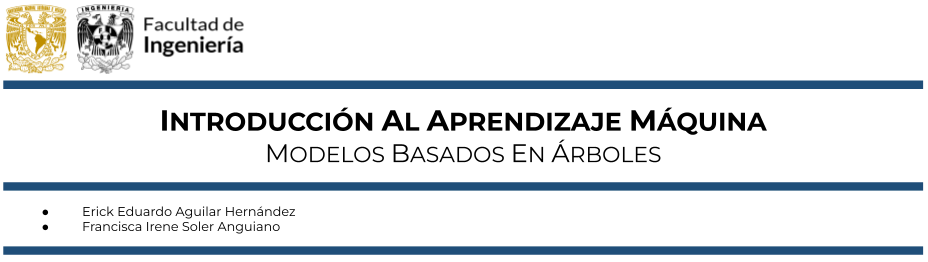

**Repositorio oficial del libro**

https://github.com/ErickEduardoAH/book-resources

**Licencia**

MIT License

---
Este notebook forma parte del material oficial que acompaña al libro *Introducción al Aprendizaje Máquina: Modelos Basados en Árboles*. Su objetivo es reproducir y ampliar los ejemplos desarrollados en el texto mediante implementaciones en Python completamente reproducibles.
___
#### Notebook 7.3.1 — Implementación: boosted trees en regresión
___

### Preparación del entorno de trabajo

En esta celda se importan las bibliotecas necesarias para estudiar **boosting** con modelos basados en árboles. Además de las herramientas usuales para manipulación de datos y visualización, se cargan utilidades para dividir la muestra, transformar variables categóricas, evaluar errores de regresión y ajustar modelos de XGBoost. Esta preparación deja listo el entorno para analizar cómo el boosting construye árboles de manera secuencial, corrigiendo gradualmente los errores de los modelos anteriores.


In [1]:
from sklearn.model_selection import train_test_split
from pathlib import Path
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)
plt.style.use('ggplot')

## Conjunto de datos: Bike Sharing Dataset (Hourly)

En este ejemplo se utilizará el conjunto de datos **Bike Sharing Dataset (Hourly)**, uno de los conjuntos de datos de regresión más utilizados para evaluar algoritmos de aprendizaje automático. El conjunto contiene registros horarios del sistema de bicicletas compartidas **Capital Bikeshare**, operado en la ciudad de Washington D.C., Estados Unidos.

El objetivo consiste en construir un modelo capaz de predecir la **demanda horaria de bicicletas** a partir de variables temporales y meteorológicas que describen las condiciones en las que se realiza cada observación.

### Variables predictoras

| Variable | Descripción |
|----------|-------------|
| `season` | Estación del año (1: primavera, 2: verano, 3: otoño, 4: invierno). |
| `yr` | Año del registro (0: 2011, 1: 2012). |
| `mnth` | Mes del año (1–12). |
| `hr` | Hora del día (0–23). |
| `holiday` | Indica si el día corresponde a un día festivo. |
| `weekday` | Día de la semana (0–6). |
| `workingday` | Indica si el día corresponde a un día laboral (no festivo ni fin de semana). |
| `weathersit` | Condición meteorológica general (despejado, nublado, lluvia ligera, nieve, etc.). |
| `temp` | Temperatura normalizada. |
| `atemp` | Sensación térmica normalizada. |
| `hum` | Humedad relativa normalizada. |
| `windspeed` | Velocidad del viento normalizada. |

### Variable respuesta

| Variable | Descripción |
|----------|-------------|
| `cnt` | Número total de bicicletas rentadas durante la hora correspondiente. |

### Preprocesamiento

Las variables categóricas (`season`, `mnth`, `hr`, `weekday` y `weathersit`) se transformarán mediante **codificación One-Hot (One-Hot Encoding)** para que puedan ser utilizadas por el modelo de aprendizaje automático.

### Observaciones

- El conjunto de datos contiene **17,379 observaciones horarias**, registradas durante los años **2011 y 2012**.
- La demanda de bicicletas depende tanto de factores **temporales** (hora del día, día de la semana, estación del año) como de factores **meteorológicos** (temperatura, humedad, velocidad del viento y condiciones climáticas).
- Este conjunto de datos constituye un excelente ejemplo para estudiar modelos de **regresión** y analizar el efecto de la selección de variables y la optimización de hiperparámetros mediante algoritmos de **boosting**, como XGBoost.

En este ejemplo se utiliza **XGBoost (Extreme Gradient Boosting)** para predecir la demanda horaria de bicicletas compartidas. XGBoost es un algoritmo de aprendizaje supervisado basado en **boosting**, una técnica de ensamble en la que múltiples árboles de decisión se construyen de manera secuencial. Cada árbol intenta corregir los errores cometidos por el conjunto de árboles previamente entrenados, permitiendo mejorar progresivamente la capacidad predictiva del modelo.

Puedes consultar la documenacion en su sitio: https://xgboost.readthedocs.io/en/stable/

### Carga local del conjunto Bike Sharing

Se carga el conjunto **Bike Sharing Dataset (Hourly)** desde el archivo `bikesharing_hour.csv` guardado en el directorio `datos`. La columna `dteday` se convierte a tipo fecha para poder extraer variables temporales adicionales, como día, semana, trimestre e indicador de fin de semana. Leer el archivo localmente evita depender de descargas externas durante la ejecución del notebook.


In [2]:
data_paths = [Path("datos") / "bikesharing_hour.csv", Path("..") / "datos" / "bikesharing_hour.csv"]
data_path = next(path for path in data_paths if path.exists())
bike_data_df = pd.read_csv(data_path)
bike_data_df["dteday"] = pd.to_datetime(bike_data_df["dteday"])
bike_data_df

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61


### Revisión de estructura y tipos de datos

La función `info()` permite revisar el número de observaciones, los tipos de variables y la presencia de valores faltantes. Esta inspección inicial ayuda a distinguir variables temporales, categóricas y numéricas antes del preprocesamiento, y confirma que la variable respuesta `cnt` está disponible para formular el problema de regresión.


In [3]:
bike_data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[us]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-null  int64

### Construcción de variables temporales y prevención de fuga de información

A partir de la fecha se crean variables temporales adicionales: día del mes, semana del año, trimestre e indicador de fin de semana. Después se eliminan columnas que no deben usarse como predictores. En particular, `casual` y `registered` introducen fuga de información (*data leakage*), porque la relación es exactamente `cnt = casual + registered`. Si se quisiera predecir la demanda futura de bicicletas para una hora determinada, todavía no se conocería cuántos usuarios casuales o registrados rentarán bicicletas en esa hora; por ello, esas variables no estarían disponibles en producción y no deben formar parte del modelo predictivo.


In [4]:
bike_data_df["day"] = bike_data_df["dteday"].dt.day
bike_data_df["week"] = bike_data_df["dteday"].dt.isocalendar().week.astype(int)
bike_data_df["quarter"] = bike_data_df["dteday"].dt.quarter
bike_data_df["is_weekend"] = (
    bike_data_df["dteday"].dt.dayofweek >= 5
).astype(int)
bike_data_df = bike_data_df.drop(
    columns=["instant", "dteday", "casual", "registered"]
)
bike_data_df

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,day,week,quarter,is_weekend
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,16,1,52,1,1
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,40,1,52,1,1
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,32,1,52,1,1
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,13,1,52,1,1
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,1,1,52,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,119,31,1,4,0
17375,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,89,31,1,4,0
17376,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,90,31,1,4,0
17377,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,61,31,1,4,0


### Codificación de variables categóricas y matriz de predictores

Las variables temporales y meteorológicas codificadas como enteros, como `season`, `mnth`, `hr`, `weekday`, `weathersit` y `quarter`, se tratan como categóricas y se transforman mediante one-hot encoding. Las variables continuas o binarias pasan sin modificación. Al final se construye la matriz numérica `X` y se separa la respuesta `y = cnt`, que representa el número total de bicicletas rentadas por hora.


In [5]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd

categoricals = [
    "season",
    "mnth",
    "hr",
    "weekday",
    "weathersit",
    "quarter",
]

numericals = [
    "yr",
    "holiday",
    "workingday",
    "temp",
    "atemp",
    "hum",
    "windspeed",
    "day",
    "week",
    "is_weekend",
]

ohe = OneHotEncoder(
    drop=None,
    sparse_output=False,
    handle_unknown="ignore"
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", ohe, categoricals),
        ("num", "passthrough", numericals),
    ],
    remainder="drop"
)

X_raw = bike_data_df.drop(columns="cnt")
y = bike_data_df["cnt"]

X_transformed = preprocessor.fit_transform(X_raw)

cat_features = (
    preprocessor
    .named_transformers_["cat"]
    .get_feature_names_out(categoricals)
)

all_features = list(cat_features) + numericals

X = pd.DataFrame(
    X_transformed,
    columns=all_features,
    index=bike_data_df.index
)
y = bike_data_df['cnt'] 
display(X)

,season_1,season_2,season_3,season_4,mnth_1,mnth_2,mnth_3,mnth_4,mnth_5,mnth_6,...,yr,holiday,workingday,temp,atemp,hum,windspeed,day,week,is_weekend
0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.24,0.2879,0.81,0.0000,1.0,52.0,1.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.22,0.2727,0.80,0.0000,1.0,52.0,1.0
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.22,0.2727,0.80,0.0000,1.0,52.0,1.0
3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.24,0.2879,0.75,0.0000,1.0,52.0,1.0
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.24,0.2879,0.75,0.0000,1.0,52.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.26,0.2576,0.60,0.1642,31.0,1.0,0.0
17375,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.26,0.2576,0.60,0.1642,31.0,1.0,0.0
17376,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.26,0.2576,0.60,0.1642,31.0,1.0,0.0
17377,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.26,0.2727,0.56,0.1343,31.0,1.0,0.0


### Separación entrenamiento-prueba

El conjunto transformado se divide en una muestra de entrenamiento y una muestra de prueba. El modelo se ajusta usando los datos de entrenamiento y se evalúa con observaciones no utilizadas durante el ajuste. Esta separación permite medir el desempeño fuera de muestra del modelo de boosting en un problema de regresión.


In [6]:
from sklearn.model_selection import train_test_split

X_train_bike, X_test_bike, y_train_bike, y_test_bike = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=123)

### Primer modelo XGBoost con variables meteorológicas

Se parte de una configuración base de `XGBRegressor` y se modifica primero el conjunto de variables utilizadas. En este primer intento se emplean principalmente variables meteorológicas y algunos indicadores generales del calendario. La idea es establecer una línea base: si solo se conocen las condiciones del clima y si el día es laboral o fin de semana, el modelo tiene información limitada para explicar la demanda horaria de bicicletas.


In [7]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

features_subset_1 = [
    "yr",
    "holiday",
    "workingday",
    "temp",
    "atemp",
    "hum",
    "windspeed",
    "is_weekend",
]

xgb_bike = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=41,
    n_jobs=-1
)

xgb_bike.fit(X_train_bike[features_subset_1], y_train_bike)

y_pred_bike = xgb_bike.predict(X_test_bike[features_subset_1])

r2 = r2_score(y_test_bike, y_pred_bike)
mae = mean_absolute_error(y_test_bike, y_pred_bike)
rmse = mean_squared_error(y_test_bike, y_pred_bike) ** 0.5

print(f"R²:   {r2:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

R²:   0.3535
MAE:  108.6097
RMSE: 146.9716


### Segundo modelo XGBoost con información temporal completa

El segundo modelo incorpora todas las variables transformadas, incluyendo información temporal como hora del día, mes, estación y día de la semana. La pregunta guía es si las condiciones meteorológicas son suficientes para predecir la demanda; la mejora del desempeño muestra que no. La demanda de bicicletas tiene una estructura temporal fuerte, por lo que variables como la hora y el calendario aportan información predictiva sustancial.


In [8]:
features_subset_2 = X_train_bike.columns

xgb_bike = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=41,
    n_jobs=-1
)

xgb_bike.fit(X_train_bike[features_subset_2], y_train_bike)

y_pred_bike = xgb_bike.predict(X_test_bike[features_subset_2])

r2 = r2_score(y_test_bike, y_pred_bike)
mae = mean_absolute_error(y_test_bike, y_pred_bike)
rmse = mean_squared_error(y_test_bike, y_pred_bike) ** 0.5

print(f"R²:   {r2:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

R²:   0.7884
MAE:  60.5465
RMSE: 84.0839


### Tercer modelo XGBoost con variables temporales sin redundancias

En este tercer ajuste se usa una selección refinada de variables. Se conservan las variables meteorológicas y temporales más útiles, pero se eliminan algunas redundancias: por ejemplo, `quarter` está determinada por el mes, y variables como `day` o `week` pueden aparecer con baja frecuencia relativa en ciertas particiones. Esta selección busca conservar la señal temporal relevante sin añadir columnas que aporten información repetida o poco estable.


In [9]:
features_subset_3 = [
    'season_1','season_2','season_3','season_4',
    'mnth_1','mnth_2','mnth_3','mnth_4','mnth_5','mnth_6',
    'mnth_7','mnth_8','mnth_9','mnth_10','mnth_11','mnth_12',
    'hr_0','hr_1','hr_2','hr_3','hr_4','hr_5','hr_6','hr_7',
    'hr_8','hr_9','hr_10','hr_11','hr_12','hr_13','hr_14',
    'hr_15','hr_16','hr_17','hr_18','hr_19','hr_20',
    'hr_21','hr_22','hr_23',
    'weekday_0','weekday_1','weekday_2','weekday_3',
    'weekday_4','weekday_5','weekday_6',
    'weathersit_1','weathersit_2','weathersit_3','weathersit_4',
    'yr',
    'holiday',
    'workingday',
    'temp',
    'atemp',
    'hum',
    'windspeed'
]

xgb_bike = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=41,
    n_jobs=-1
)

xgb_bike.fit(X_train_bike[features_subset_3], y_train_bike)

y_pred_bike = xgb_bike.predict(X_test_bike[features_subset_3])

r2 = r2_score(y_test_bike, y_pred_bike)
mae = mean_absolute_error(y_test_bike, y_pred_bike)
rmse = mean_squared_error(y_test_bike, y_pred_bike) ** 0.5

print(f"R²:   {r2:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

R²:   0.7910
MAE:  60.1742
RMSE: 83.5600


### Optimización de hiperparámetros con GridSearchCV

Una vez definido el conjunto de variables, se optimizan los hiperparámetros principales del modelo mediante una búsqueda exhaustiva en malla. `GridSearchCV` evalúa combinaciones de `n_estimators`, `learning_rate` y `max_depth` usando validación cruzada de 5 folds y selecciona la configuración con mayor $R^2$ promedio. Este paso refleja la lógica del boosting: controlar simultáneamente cuántos árboles se agregan, qué tan fuerte aprende cada árbol y qué tan complejos son los árboles individuales.


In [10]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

xgb_bike = XGBRegressor(
    objective="reg:squarederror",
    random_state=41,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7]
}

grid_search = GridSearchCV(
    estimator=xgb_bike,
    param_grid=param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(
    X_train_bike[features_subset_3],
    y_train_bike
)

print("Mejores hiperparámetros:")
print(grid_search.best_params_)

print("\nMejor R² promedio (validación cruzada):")
print(grid_search.best_score_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Mejores hiperparámetros:
{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300}

Mejor R² promedio (validación cruzada):
0.9316507577896118


### Resultados de la búsqueda de hiperparámetros

Los resultados de `GridSearchCV` se convierten en una tabla ordenada por `rank_test_score`. Esto permite comparar las mejores configuraciones evaluadas, revisar el $R^2$ promedio de validación cruzada y observar la variabilidad entre folds mediante `std_test_score`. La tabla ayuda a entender si el mejor modelo destaca claramente o si varias configuraciones producen desempeños similares.


In [11]:
results = pd.DataFrame(grid_search.cv_results_)
results = results[
    [
        "param_n_estimators",
        "param_learning_rate",
        "param_max_depth",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score")
results.head(10)

,param_n_estimators,param_learning_rate,param_max_depth,mean_test_score,std_test_score,rank_test_score
26,300,0.10,7,0.931651,0.003736,1
25,200,0.10,7,0.928369,0.004068,2
17,300,0.05,7,0.923421,0.003806,3
23,300,0.10,5,0.923315,0.004408,4
22,200,0.10,5,0.913359,0.005240,5
24,100,0.10,7,0.911721,0.005860,6
16,200,0.05,7,0.910239,0.003491,7
14,300,0.05,5,0.902314,0.005151,8
20,300,0.10,3,0.879314,0.004347,9
21,100,0.10,5,0.872443,0.007187,10


### Evaluación del modelo optimizado en prueba

Se recupera el mejor estimador encontrado por `GridSearchCV` y se evalúa en el conjunto de prueba. El modelo optimizado explica aproximadamente el 94.04% de la variabilidad observada en la demanda de bicicletas. En promedio, las predicciones presentan un error absoluto cercano a 29 alquileres por hora, mientras que el RMSE, cercano a 44.61, indica que algunas observaciones tienen errores mayores porque esta métrica penaliza más las desviaciones grandes. El $R^2$ de prueba es ligeramente superior al promedio de validación cruzada, con una diferencia pequeña, por lo que no hay una señal evidente de sobreajuste causado por la búsqueda de hiperparámetros.


In [12]:
best_bike_model = grid_search.best_estimator_
y_pred = best_bike_model.predict(X_test_bike[features_subset_3])

r2 = r2_score(y_test_bike, y_pred)
mae = mean_absolute_error(y_test_bike, y_pred)
rmse = mean_squared_error(y_test_bike, y_pred) ** 0.5

print(f"R²:   {r2:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

R²:   0.9404
MAE:  28.9723
RMSE: 44.6140


### Comparación de los modelos ajustados

La siguiente tabla resume la evolución de los modelos construidos durante el notebook. La comparación permite separar dos efectos: por un lado, el impacto de agregar variables más informativas; por otro, el efecto de optimizar los hiperparámetros del modelo de boosting. En el primer modelo se usan principalmente variables meteorológicas, por lo que el desempeño es limitado: las condiciones del clima ayudan, pero no capturan por sí solas los patrones de uso del sistema de bicicletas. Al incorporar variables temporales, como hora, mes, estación y día de la semana, el desempeño mejora de forma importante, lo que confirma que la demanda tiene una estructura temporal fuerte. Finalmente, la búsqueda con `GridSearchCV` ajusta la complejidad del ensamble y produce el mejor balance entre sesgo y varianza.

| Modelo | Variables utilizadas | Optimización | R² | MAE | RMSE |
|:--------|:---------------------|:------------:|---:|---:|---:|
| Modelo 1 | Variables meteorológicas (`yr`, `holiday`, `workingday`, `temp`, `atemp`, `hum`, `windspeed`, `is_weekend`) | No | 0.3535 | 108.6097 | 146.9716 |
| Modelo 2 | Variables meteorológicas y temporales (selección refinada) | No | 0.7910 | 60.1742 | 83.5600 |
| Modelo 3 | Variables meteorológicas y temporales (selección refinada) | Sí (`GridSearchCV`) | **0.9404** | **28.9723** | **44.6140** |

La lectura conjunta de las métricas muestra que el Modelo 3 es claramente superior: alcanza el mayor $R^2$ y reduce tanto el MAE como el RMSE. Esto significa que no solo explica una mayor proporción de la variabilidad de `cnt`, sino que también disminuye el error promedio de predicción. La diferencia entre MAE y RMSE recuerda que algunos horarios presentan errores más grandes, algo esperable en datos de demanda horaria donde pueden existir picos por patrones de traslado, clima o calendario.


### Importancia de variables del modelo XGBoost optimizado

Finalmente se calculan las importancias de variables del mejor modelo de XGBoost. Estas importancias resumen qué predictores participaron con mayor peso en las particiones de los árboles del ensamble. En este problema, las variables temporales suelen ser especialmente relevantes porque la demanda de bicicletas cambia mucho según la hora del día, el mes, la estación y el tipo de día; las variables meteorológicas complementan esa señal al capturar condiciones que pueden favorecer o inhibir el uso del sistema.


<Axes: xlabel='importance', ylabel='variable'>

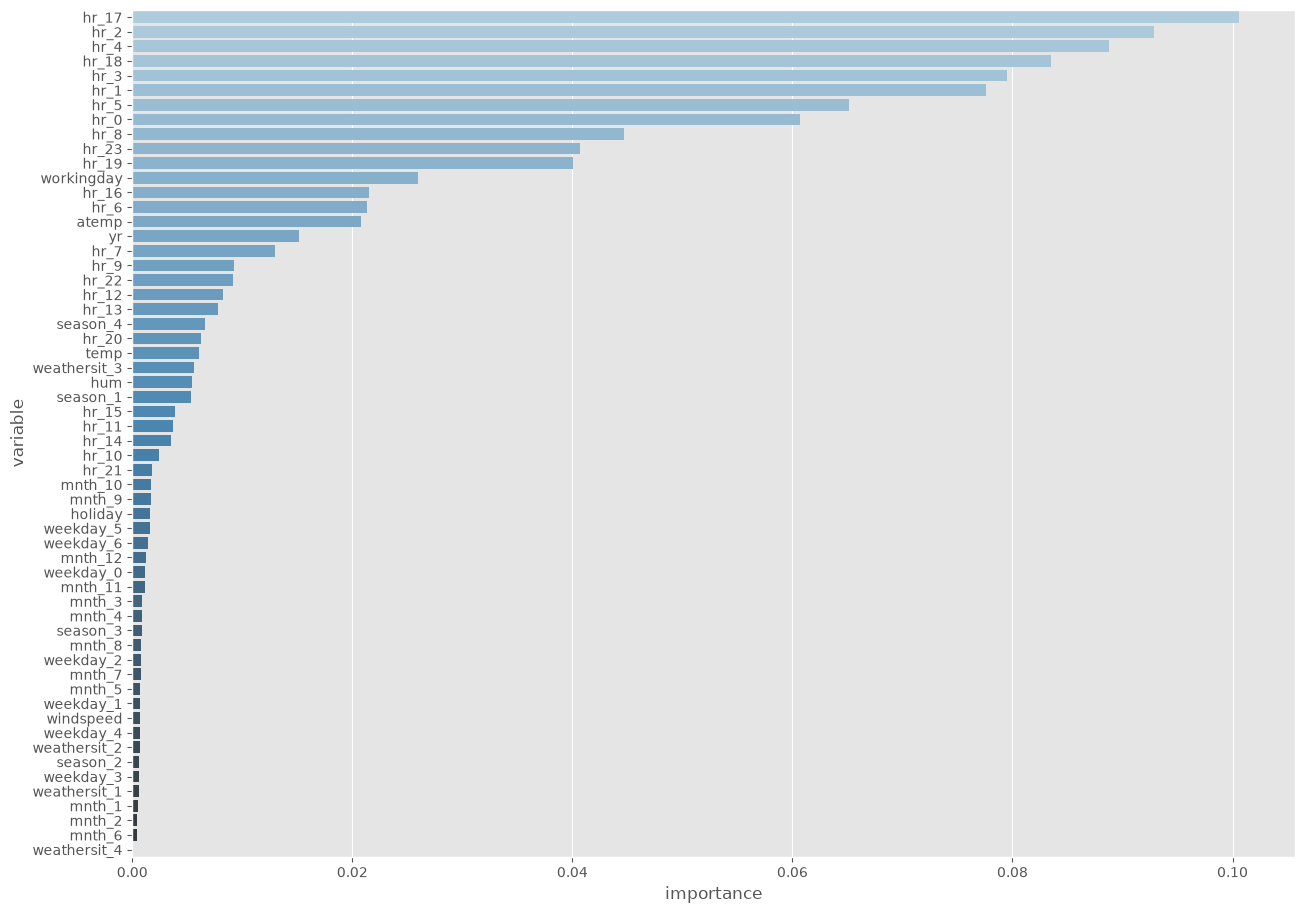

In [13]:
importances_df = pd.DataFrame([features_subset_3,
                               best_bike_model.feature_importances_])\
                   .transpose()
importances_df.columns = ['variable','importance']
importances_df.sort_values('importance',ascending=False,inplace=True)


plt.figure(figsize=(15,11))
sns.barplot(y="variable",
            x="importance",
            data=importances_df,
            palette="Blues_d")

___
#### Notebook 7.3.2 — Implementación: random forest en clasificación
___


En los capítulos anteriores se trabajo con el dataset de creditg.csv y se observó que un árbol de decisión individual presenta una elevada varianza y puede sobreajustarse fácilmente. Aunque técnicas como la poda y la validación cruzada ayudan a mejorar su capacidad de generalización, todavía existen limitaciones en su desempeño predictivo. En este ejemplo se empleará XGBoost, un algoritmo basado en árboles potenciados (boosted trees), con el objetivo de analizar si es posible obtener un mejor desempeño sobre el mismo conjunto de datos.

### Notebook 8.2 — Implementación: XGBoost en clasificación

En esta segunda parte se utiliza **XGBoost** para un problema de clasificación binaria con el conjunto German Credit. El objetivo es estimar la probabilidad de que un crédito pertenezca a la clase `good`, comparando primero una configuración base y después una versión optimizada mediante validación cruzada.


### Carga local del conjunto German Credit

Se carga el conjunto **German Credit** desde el archivo `credit-g.csv` almacenado en `datos`. Este conjunto describe solicitudes de crédito mediante variables numéricas y categóricas, y la variable respuesta `class` distingue entre créditos `good` y `bad`. La visualización transpuesta de las primeras observaciones facilita revisar los nombres de las variables y el tipo de información disponible antes del preprocesamiento.


In [14]:
data_paths = [Path("datos") / "credit-g.csv", Path("..") / "datos" / "credit-g.csv"]
data_path = next(path for path in data_paths if path.exists())
credit_data_df = pd.read_csv(data_path)
credit_data_df.head(5).transpose()

,0,1,2,3,4
checking_status,<0,0<=X<200,no checking,<0,<0
duration,6,48,12,42,24
credit_history,critical/other existing credit,existing paid,critical/other existing credit,existing paid,delayed previously
purpose,radio/tv,radio/tv,education,furniture/equipment,new car
credit_amount,1169,5951,2096,7882,4870
savings_status,no known savings,<100,<100,<100,<100
employment,>=7,1<=X<4,4<=X<7,4<=X<7,1<=X<4
installment_commitment,4,2,2,2,3
personal_status,male single,female div/dep/mar,male single,male single,male single
other_parties,none,none,none,guarantor,none


### Codificación de variables y partición de datos

Las variables categóricas del conjunto German Credit se transforman mediante one-hot encoding, mientras que las variables numéricas pasan sin modificación. Después se limpian los nombres de columnas para sustituir caracteres que XGBoost no admite, como signos de desigualdad o corchetes. La respuesta `class` se codifica como una variable binaria, donde `good` toma el valor 1 y `bad` el valor 0. Finalmente, los datos se dividen en entrenamiento y prueba para evaluar el desempeño fuera de muestra.


In [15]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import re

def clean_feature_name(name):
    name = str(name)
    replacements = {
        "<=": "_leq_",
        ">=": "_geq_",
        "<": "_le_",
        ">": "_ge_",
        "[": "_",
        "]": "_"
    }
    for old, new in replacements.items():
        name = name.replace(old, new)
    name = re.sub(r"_+", "_", name)
    name = name.strip("_")
    return name


categoricals = [
    "checking_status",
    "credit_history",
    "purpose",
    "savings_status",
    "employment",
    "personal_status",
    "other_parties",
    "property_magnitude",
    "other_payment_plans",
    "housing",
    "job",
    "own_telephone",
    "foreign_worker"
]

numericals = [
    "duration",
    "credit_amount",
    "installment_commitment",
    "residence_since",
    "age",
    "existing_credits",
    "num_dependents"
]

ohe = OneHotEncoder(
    drop=None,           # no elimina categorías
    sparse_output=False, # devuelve DataFrame usable
    handle_unknown="ignore"
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", ohe, categoricals),
        ("num", "passthrough", numericals)
    ]
)

X_transformed = preprocessor.fit_transform(credit_data_df)

cat_features = preprocessor.named_transformers_["cat"].get_feature_names_out(categoricals)

all_features = list(cat_features) + numericals

import re

X = pd.DataFrame(
    X_transformed,
    columns=all_features
)

X.columns = [clean_feature_name(col) for col in X.columns]

y = (credit_data_df["class"] == "good").astype(int)


X_train_credit, X_test_credit, y_train_credit, y_test_credit = train_test_split(
    X, y, test_size=0.3, random_state=42
)
X_train_credit

,checking_status_0_leq_X_le_200,checking_status_le_0,checking_status_geq_200,checking_status_no checking,credit_history_all paid,credit_history_critical/other existing credit,credit_history_delayed previously,credit_history_existing paid,credit_history_no credits/all paid,purpose_business,...,own_telephone_yes,foreign_worker_no,foreign_worker_yes,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents
541,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,24.0,2032.0,4.0,4.0,60.0,2.0,1.0
440,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,12.0,1884.0,4.0,4.0,39.0,1.0,1.0
482,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,30.0,3622.0,4.0,4.0,57.0,2.0,1.0
422,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,12.0,958.0,2.0,3.0,47.0,2.0,2.0
778,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,36.0,5711.0,4.0,2.0,38.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,18.0,6458.0,2.0,4.0,39.0,2.0,2.0
270,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,18.0,2662.0,4.0,3.0,32.0,1.0,1.0
860,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,24.0,5804.0,4.0,2.0,27.0,2.0,1.0
435,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,12.0,1484.0,2.0,1.0,25.0,1.0,1.0


### Ajuste inicial de XGBoost para clasificación

Se ajusta un `XGBClassifier` con una configuración base para predecir la clase del crédito. El modelo usa la función logística binaria, adecuada cuando la respuesta tiene dos clases, y la métrica interna `logloss` para guiar el entrenamiento. Después del ajuste se generan predicciones sobre el conjunto de prueba y se presenta una matriz de confusión. Como la codificación usada es `bad = 0` y `good = 1`, la matriz permite distinguir cuántos créditos malos y buenos fueron clasificados correcta o incorrectamente.


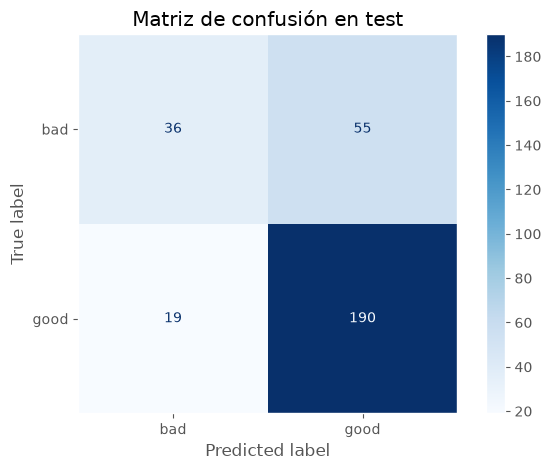

In [16]:
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt


xgb_credit = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=41,
    n_jobs=-1
).fit(
    X_train_credit,
    y_train_credit
)

y_pred_credit_test = xgb_credit.predict(X_test_credit)

cm_df = pd.DataFrame(
    confusion_matrix(y_test_credit, y_pred_credit_test),
    index=["Real: bad", "Real: good"],
    columns=["Pred: bad", "Pred: good"]
)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_df.values,
    display_labels=["bad", "good"]
)
disp.plot(cmap="Blues")
plt.title("Matriz de confusión en test")
plt.grid(False)
plt.tight_layout()
plt.show()

### Curva ROC del modelo XGBoost inicial

En la sección de árboles de clasificación, el árbol individual alcanzaba aproximadamente un AUC de entrenamiento cercano a 0.89 y un AUC de prueba cercano a 0.71. Con el modelo inicial de boosting, el desempeño sube a alrededor de 0.957 en entrenamiento y 0.781 en prueba. La mejora es clara, pero la diferencia entre entrenamiento y prueba todavía sugiere cierto sobreajuste. Por ello se analiza la curva ROC y posteriormente se buscará reducir esa brecha mediante validación cruzada y ajuste de hiperparámetros.


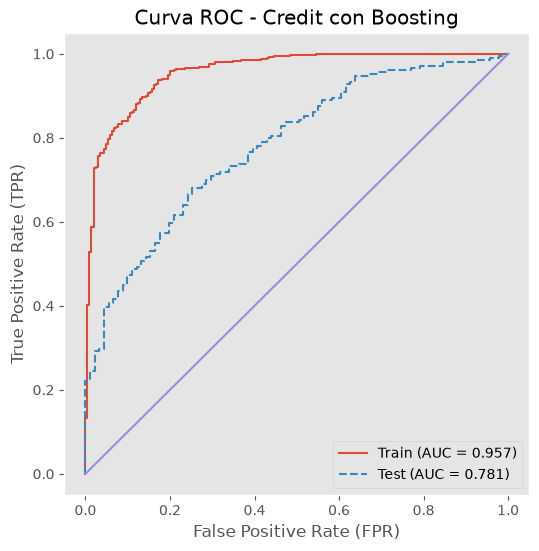

In [17]:
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve

y_train_prob = xgb_credit.predict_proba(X_train_credit)[:, 1]
y_test_prob = xgb_credit.predict_proba(X_test_credit)[:, 1]

fpr_train, tpr_train, _ = roc_curve(y_train_credit, y_train_prob)
fpr_test, tpr_test, _   = roc_curve(y_test_credit, y_test_prob)
auc_train = roc_auc_score(y_train_credit, y_train_prob)
auc_test  = roc_auc_score(y_test_credit, y_test_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr_train, tpr_train, label=f"Train (AUC = {auc_train:.3f})")
plt.plot(fpr_test, tpr_test, linestyle="--", label=f"Test (AUC = {auc_test:.3f})")

plt.plot([0,1], [0,1])
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Curva ROC - Credit con Boosting")
plt.legend()
plt.grid()
plt.show()

### Distribución de probabilidades estimadas por clase

En el árbol de decisión simple se observaba una doble moda bastante marcada. Esto ocurría porque un árbol asigna probabilidades discretas: todas las observaciones que caen en una misma hoja reciben exactamente la misma probabilidad, produciendo varios picos en la distribución. En XGBoost, al combinar muchos árboles de forma secuencial, las probabilidades estimadas suelen ser más graduales. Las curvas KDE permiten comparar cómo se distribuyen los puntajes del modelo para las clases observadas en entrenamiento y prueba.


<>:33: SyntaxWarning: invalid escape sequence '\h'
<>:35: SyntaxWarning: invalid escape sequence '\h'
<>:33: SyntaxWarning: invalid escape sequence '\h'
<>:35: SyntaxWarning: invalid escape sequence '\h'
/var/folders/x2/5_fz4cv53wvft743tfdfxl_r0000gn/T/ipykernel_54746/4180066129.py:33: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel("Probabilidad estimada $\hat{p}(x)$")
/var/folders/x2/5_fz4cv53wvft743tfdfxl_r0000gn/T/ipykernel_54746/4180066129.py:35: SyntaxWarning: invalid escape sequence '\h'
  plt.title("Distribuciones KDE de $\hat{p}(x)$ para clases positivas y negativas")


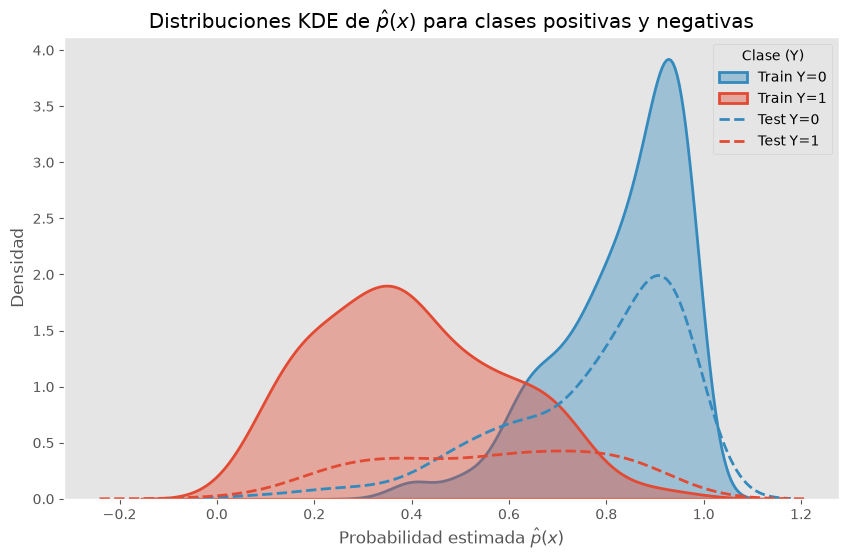

In [18]:
train_df = pd.DataFrame({
    "score": y_train_prob,
    "Y": y_train_credit
})

test_df = pd.DataFrame({
    "score": y_test_prob,
    "Y": y_test_credit
})

plt.figure(figsize=(10,6))

sns.kdeplot(
    data=train_df,
    x="score",
    hue="Y",
    fill=True,
    common_norm=False,
    alpha=0.4,
    linewidth=2,
    label=None
)

sns.kdeplot(
    data=test_df,
    x="score",
    hue="Y",
    fill=False,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Probabilidad estimada $\hat{p}(x)$")
plt.ylabel("Densidad")
plt.title("Distribuciones KDE de $\hat{p}(x)$ para clases positivas y negativas")
plt.legend(title="Clase (Y)", labels=["Train Y=0", "Train Y=1", "Test Y=0", "Test Y=1"])
plt.grid()
plt.show()

### Búsqueda de hiperparámetros con validación cruzada

Para mejorar la generalización del modelo, se evalúan distintas configuraciones de XGBoost mediante `GridSearchCV`. La búsqueda modifica el número de árboles, la tasa de aprendizaje, la profundidad máxima, el peso mínimo por hijo y las proporciones de filas y columnas usadas por árbol. La métrica de selección es `roc_auc`, porque interesa la capacidad del modelo para ordenar correctamente créditos `good` frente a créditos `bad` a través de distintos umbrales de decisión.


In [19]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

xgb_credit = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=41,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [i for i in range(40,60,1)],
    "learning_rate": [0.2, 0.25],
    "max_depth": [2, 3, 4],
    "min_child_weight": [5],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "subsample": [0.7, 0.8, 0.9, 1.0]
}

grid_search = GridSearchCV(
    estimator=xgb_credit,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(
    X_train_credit,
    y_train_credit
)

print("Mejores hiperparámetros:")
print(grid_search.best_params_)

print("\nMejor AUC promedio (validación cruzada):")
print(grid_search.best_score_)


Fitting 5 folds for each of 1440 candidates, totalling 7200 fits
Mejores hiperparámetros:
{'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 2, 'min_child_weight': 5, 'n_estimators': 47, 'subsample': 0.8}

Mejor AUC promedio (validación cruzada):
0.7655003063415209


### Resultados del Grid Search

Los resultados de la búsqueda se organizan en una tabla con las configuraciones evaluadas, su AUC promedio en validación cruzada, la desviación estándar entre folds y el ranking de desempeño. Esta tabla permite revisar si la mejor configuración destaca claramente o si varias combinaciones tienen resultados similares, lo cual es útil para elegir un modelo que no sea innecesariamente complejo.


In [20]:
results = pd.DataFrame(grid_search.cv_results_)
results = results[
    [
        "param_n_estimators",
        "param_learning_rate",
        "param_max_depth",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score")
results.head(10)

,param_n_estimators,param_learning_rate,param_max_depth,mean_test_score,std_test_score,rank_test_score
509,47,0.20,2,0.765500,0.041787,1
148,57,0.20,3,0.765329,0.040077,2
176,44,0.20,4,0.765232,0.046216,3
152,58,0.20,3,0.765047,0.040046,4
144,56,0.20,3,0.765043,0.041604,5
556,59,0.20,2,0.764906,0.044066,6
112,48,0.20,3,0.764693,0.046960,7
132,53,0.20,3,0.764665,0.041636,8
180,45,0.20,4,0.764599,0.046405,9
752,48,0.25,2,0.764555,0.046002,10


### Matriz de confusión del modelo optimizado

Se recupera el mejor modelo encontrado por validación cruzada y se evalúa de nuevo en la muestra de prueba. La matriz de confusión permite observar el efecto práctico de la optimización: no solo interesa mejorar el AUC, sino también revisar qué tipo de errores comete el modelo al clasificar créditos `bad` y `good`.


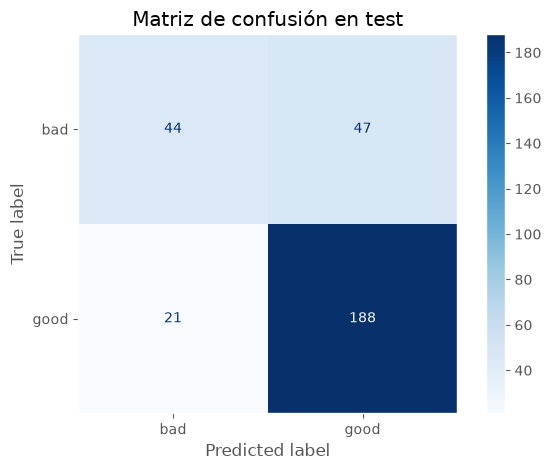

In [21]:
best_credit_model = grid_search.best_estimator_
y_pred_credit_test = best_credit_model.predict(X_test_credit)

cm_df = pd.DataFrame(
    confusion_matrix(y_test_credit, y_pred_credit_test),
    index=["Real: bad", "Real: good"],
    columns=["Pred: bad", "Pred: good"]
)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_df.values,
    display_labels=["bad", "good"]
)
disp.plot(cmap="Blues")
plt.title("Matriz de confusión en test")
plt.grid(False)
plt.tight_layout()
plt.show()

### Curva ROC del modelo optimizado

Después de evaluar diversas configuraciones de hiperparámetros mediante validación cruzada, se obtuvo un AUC cercano a 0.80 sobre el conjunto de prueba. A partir de este punto, modificaciones adicionales de los hiperparámetros produjeron únicamente mejoras marginales, por lo que se seleccionó el modelo más parsimonioso con mejor capacidad de generalización. Además, con un conjunto de prueba de solo 300 ejemplos, un cambio de 0.005 en el AUC puede deberse simplemente a la partición aleatoria; por eso conviene interpretar pequeñas diferencias con cautela.


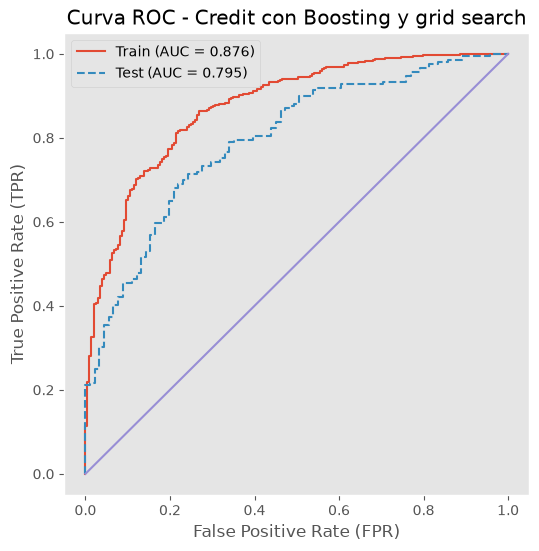

In [22]:
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve

y_train_prob = best_credit_model.predict_proba(X_train_credit)[:, 1]
y_test_prob = best_credit_model.predict_proba(X_test_credit)[:, 1]

fpr_train, tpr_train, _ = roc_curve(y_train_credit, y_train_prob)
fpr_test, tpr_test, _   = roc_curve(y_test_credit, y_test_prob)
auc_train = roc_auc_score(y_train_credit, y_train_prob)
auc_test  = roc_auc_score(y_test_credit, y_test_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr_train, tpr_train, label=f"Train (AUC = {auc_train:.3f})")
plt.plot(fpr_test, tpr_test, linestyle="--", label=f"Test (AUC = {auc_test:.3f})")

plt.plot([0,1], [0,1])
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Curva ROC - Credit con Boosting y grid search")
plt.legend()
plt.grid()
plt.show()

### Comparación de los modelos

| Modelo | Variables utilizadas | Optimización | AUC (Train) | AUC (Test) | Brecha |
|:--------|:---------------------|:------------:|------------:|-----------:|--------:|
| Árbol de clasificación con ccp-apha| Selección manual | No | 0.872 | 0.711 | 0.161 |
| XGBoost | Selección manual | No | 0.957 | 0.781 | 0.176 |
| XGBoost | Todas las variables | Sí (`GridSearchCV`) | **0.876** | **0.795** | **0.081** |

La Tabla anterior muestra la evolución del desempeño de los distintos modelos evaluados sobre el conjunto de datos de créditos alemanes.

El árbol de decisión constituye la línea base del estudio, obteniendo un AUC de **0.711** sobre el conjunto de prueba. Al reemplazar el árbol individual por un modelo basado en **XGBoost**, el AUC aumenta hasta **0.781**, aunque con una diferencia considerable entre el desempeño en entrenamiento y prueba, indicando la presencia de sobreajuste.

Finalmente, al incorporar todas las variables predictoras y optimizar los hiperparámetros mediante **GridSearchCV**, se obtiene el mejor modelo. Aunque el AUC de entrenamiento disminuye respecto al modelo inicial de XGBoost, el AUC sobre el conjunto de prueba aumenta hasta **0.795**, reduciendo además la diferencia entre entrenamiento y prueba de **0.176** a **0.081**. Esto indica una mejora en la capacidad de generalización del modelo y evidencia la importancia de la selección adecuada de hiperparámetros en algoritmos de boosting.
